In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.preprocessing    import MinMaxScaler
from sklearn.ensemble         import RandomForestClassifier
from sklearn.model_selection  import train_test_split

In [9]:
saved_data = joblib.load('/content/rf_model_youden.joblib')
print("Youden Threshold:", saved_data['threshold'])


Youden Threshold: 0.5310948920829409


Selected instances:
  [TP — Endometriosis, correctly identified]  true=1  pred=1  proba=1.000
  [TN — No endometriosis, correctly identified]  true=0  pred=0  proba=0.000
  [FP — No endometriosis, flagged as high-risk]  true=0  pred=1  proba=0.652
  [FN — Endometriosis, missed by model]  true=1  pred=0  proba=0.490


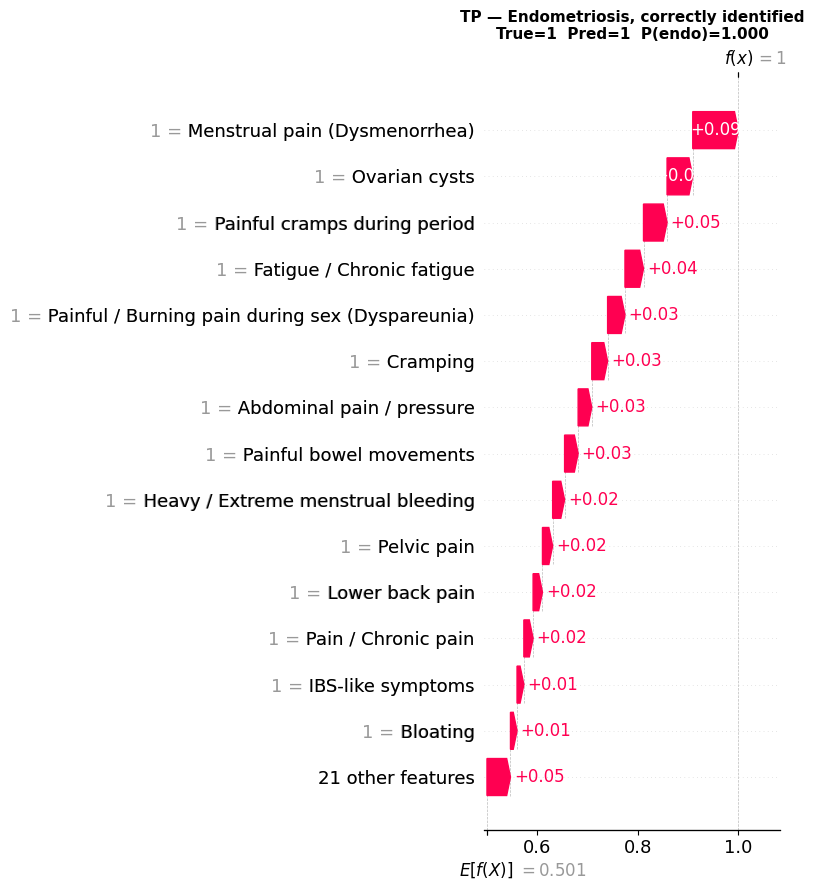

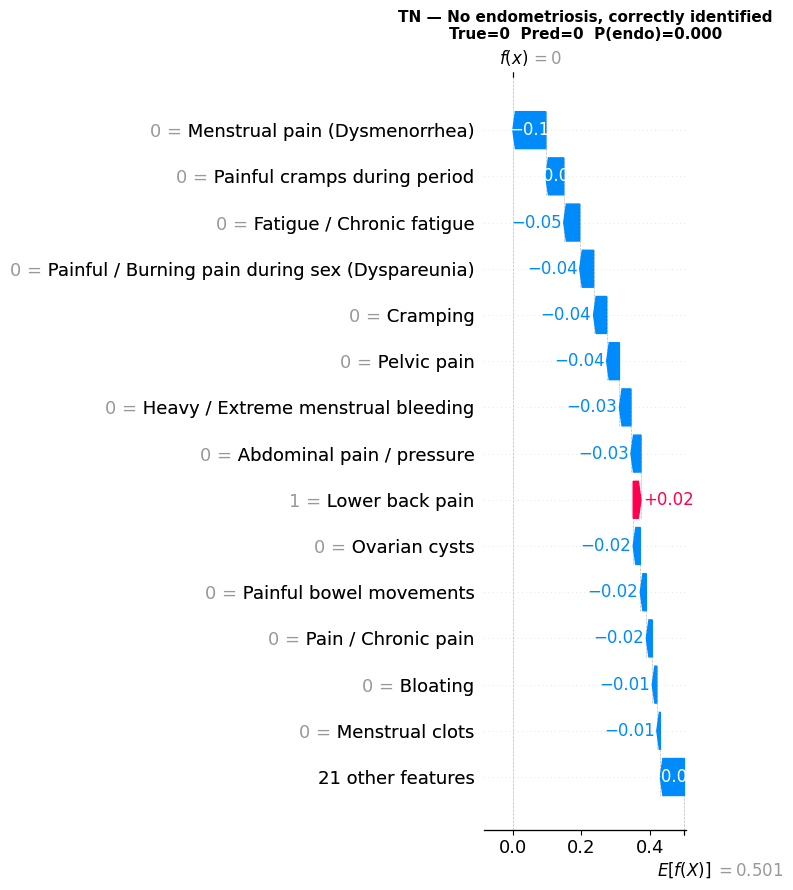

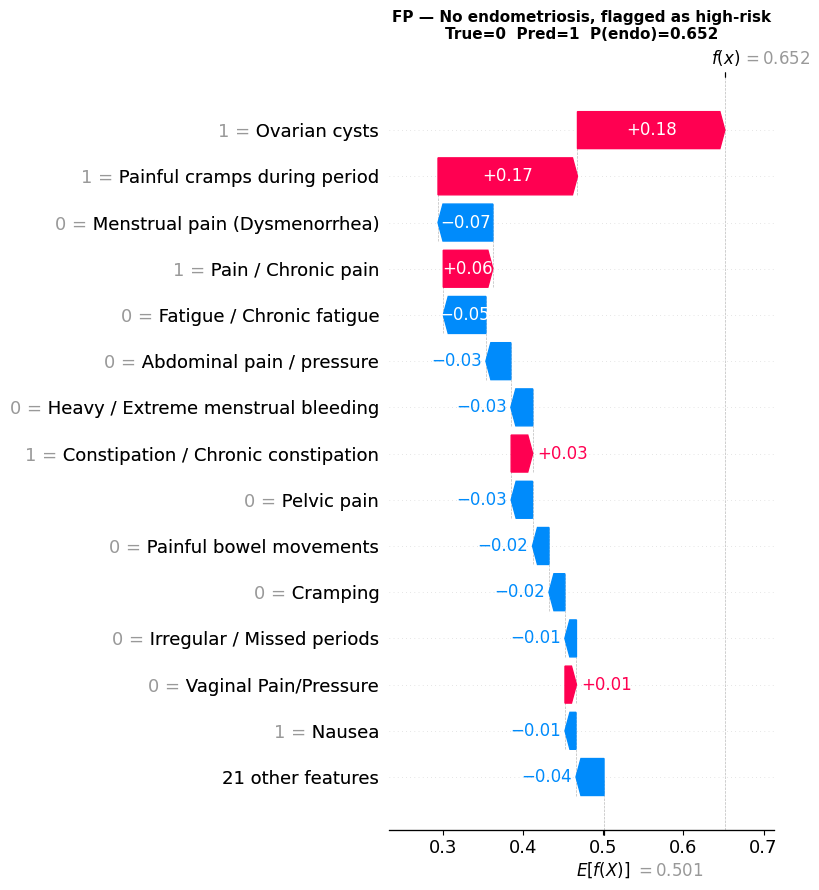

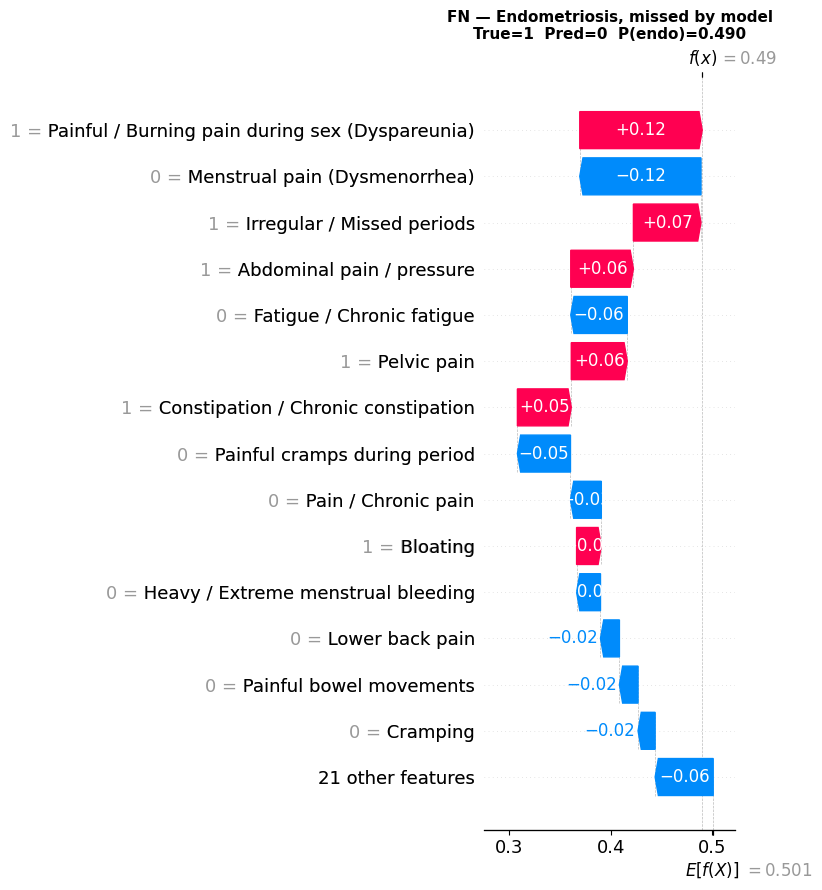

  Force plot saved: SHAP_local_TP_force.html
  Force plot saved: SHAP_local_TN_force.html
  Force plot saved: SHAP_local_FP_force.html
  Force plot saved: SHAP_local_FN_force.html

Done — 4 waterfall plots + 4 force plots saved in /content/Figures
CSV summary saved in /content/Results


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.model_selection import train_test_split

BASE_DIR = '/content'
FIGURES_DIR = os.path.join(BASE_DIR, 'Figures')
RESULTS_DIR = os.path.join(BASE_DIR, 'Results')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

df = pd.read_excel("/content/dataset.xlsx", engine="openpyxl")
y = df["label"].astype(int)
X = df.drop(columns=["Unnamed: 0", "row", "label"], errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
saved_data = joblib.load('/content/rf_model_youden.joblib')
rf = saved_data['model']
YOUDEN_THRESHOLD = saved_data['threshold']
FINAL_FEATURES = pd.read_csv('/content/FINAL_35_features_selected.csv')['feature'].tolist()
X_test_fs = X_test[FINAL_FEATURES]
y_proba = rf.predict_proba(X_test_fs)[:, 1]
y_pred = (y_proba >= YOUDEN_THRESHOLD).astype(int)

test_df = X_test_fs.copy()
test_df['true_label'] = y_test.values
test_df['pred_label'] = y_pred
test_df['proba'] = y_proba

tp = test_df[(test_df['true_label'] == 1) & (test_df['pred_label'] == 1)].copy()
tn = test_df[(test_df['true_label'] == 0) & (test_df['pred_label'] == 0)].copy()
fp = test_df[(test_df['true_label'] == 0) & (test_df['pred_label'] == 1)].copy()
fn = test_df[(test_df['true_label'] == 1) & (test_df['pred_label'] == 0)].copy()

idx_tp = tp['proba'].idxmax()
idx_tn = tn['proba'].idxmin()
idx_fp = fp['proba'].sub(YOUDEN_THRESHOLD).abs().idxmin()
idx_fn = fn['proba'].sub(YOUDEN_THRESHOLD).abs().idxmin()

instances = {
    'TP — Endometriosis, correctly identified': idx_tp,
    'TN — No endometriosis, correctly identified': idx_tn,
    'FP — No endometriosis, flagged as high-risk': idx_fp,
    'FN — Endometriosis, missed by model': idx_fn,
}

print("Selected instances:")
for label, idx in instances.items():
    row = test_df.loc[idx]
    print(f"  [{label}]  true={int(row['true_label'])}  pred={int(row['pred_label'])}  proba={row['proba']:.3f}")

summary = pd.DataFrame([{
    'Instance': label,
    'Index': idx,
    'True label': int(test_df.loc[idx, 'true_label']),
    'Pred label': int(test_df.loc[idx, 'pred_label']),
    'Probability': round(test_df.loc[idx, 'proba'], 4),
} for label, idx in instances.items()])
summary.to_csv(os.path.join(RESULTS_DIR, 'SHAP_4_instances_summary.csv'), index=False)
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test_fs)
sv_class1 = shap_values[:, :, 1]

test_positions = {idx: pos for pos, idx in enumerate(X_test_fs.index)}

short_labels = {
    'TP — Endometriosis, correctly identified': 'TP',
    'TN — No endometriosis, correctly identified': 'TN',
    'FP — No endometriosis, flagged as high-risk': 'FP',
    'FN — Endometriosis, missed by model': 'FN',
}
for label, idx in instances.items():
    pos = test_positions[idx]
    row = test_df.loc[idx]
    tag = short_labels[label]

    fig, ax = plt.subplots(figsize=(10, 6))
    shap.plots.waterfall(sv_class1[pos], max_display=15, show=False)
    plt.title(f'{label}\nTrue={int(row["true_label"])}  Pred={int(row["pred_label"])}  P(endo)={row["proba"]:.3f}',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f'SHAP_local_{tag}_waterfall.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

shap.initjs()
for label, idx in instances.items():
    pos = test_positions[idx]
    tag = short_labels[label]
    fp_plot = shap.force_plot(
        explainer.expected_value[1],
        shap_values.values[pos, :, 1],
        X_test_fs.iloc[pos],
        feature_names=FINAL_FEATURES,
        show=False
    )
    shap.save_html(
        os.path.join(FIGURES_DIR, f'SHAP_local_{tag}_force.html'), fp_plot
    )
    print(f"  Force plot saved: SHAP_local_{tag}_force.html")

print("\nDone — 4 waterfall plots + 4 force plots saved in", FIGURES_DIR)
print("CSV summary saved in", RESULTS_DIR)
